#Hard-margin and Soft-margin SVM (Implementing Quadratic Programs in SciPy)

In this assignment you will implement **hard-margin** and **soft-margin** Support Vector Machines by **writing the appropriate constraints** in their corresponding optimization problems.

You will:
1. Load a **real dataset**, project it to 2D, and **plot the data** (code provided).
2. Formulate the **hard-margin SVM** as a quadratic program (QP) and encode its constraints for a solver.
3. Formulate the **soft-margin SVM** as a QP with **slack variables**.
4. Visualize the decision boundary and margins.

We use **SciPy**’s constrained optimizer (`trust-constr`) as the QP solver interface.  
(Internally this is a general-purpose constrained optimizer; we provide it with a convex quadratic objective and linear constraints.)

---

## Background: SVM

Given labeled examples $(x_i, y_i)$ with $y_i \in \{-1, +1\}$, a linear classifier is $f(x)=\mathrm{sign}(w^\top x + b)$.

- **Hard-margin SVM** (requires separability):
$$
\min_{w,b}\ \frac{1}{2}\lVert w\rVert^2
\quad \text{s.t.}\quad y_i(w^\top x_i + b) \ge 1\ \ \forall i.
$$
- **Soft-margin SVM** (allows violations via slack $\xi_i \ge 0$):
$$
\min_{w,b,\xi}\ \frac{1}{2}\lVert w\rVert^2 + C\sum_i \xi_i
\quad \text{s.t.}\quad y_i(w^\top x_i + b) \ge 1 - \xi_i,\ \xi_i\ge 0.
$$

The parameter $C>0$ trades off **margin size** vs **constraint violations**.

---

## Data: real dataset, projected to 2D

We use the **Breast Cancer Wisconsin** dataset from scikit-learn, then standardize and project to **2D** with PCA.  
In 2D, this dataset is **not linearly separable**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint, Bounds

np.set_printoptions(precision=4, suppress=True)

## Load + preprocess

- Standardize features (important for margin-based methods).
- PCA to 2D for visualization.
- Subsample to keep the geometry clear and the solver fast.

In [2]:
# Load dataset
data = load_breast_cancer()
X_raw = data.data
y01 = data.target  # 0/1 labels

# Convert labels to {-1, +1}
y = 2 * y01 - 1

# Standardize then project to 2D
X_std = StandardScaler().fit_transform(X_raw)
X_2d = PCA(n_components=2, random_state=0).fit_transform(X_std)

# Subsample (deterministic)
rng = np.random.default_rng(0)
idx = rng.choice(len(X_2d), size=120, replace=False)
X = X_2d[idx]
y = y[idx]

n, d = X.shape
assert d == 2

print("n =", n, "  d =", d)
print("Class balance (+1):", np.mean(y == 1), "(-1):", np.mean(y == -1))

n = 120   d = 2
Class balance (+1): 0.575 (-1): 0.425


## Subtask 1 — Plot the data

Run the cell to see that the two classes overlap in 2D (not linearly separable).

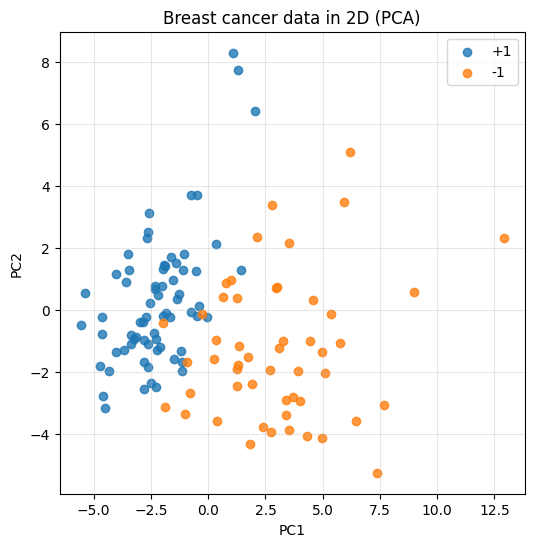

In [3]:
def plot_data_2d(X, y, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(X[y == 1, 0], X[y == 1, 1], label="+1", alpha=0.8)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], label="-1", alpha=0.8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title)
    ax.legend(loc="best")
    return ax

fig, ax = plt.subplots(figsize=(6, 6))
plot_data_2d(X, y, ax=ax, title="Breast cancer data in 2D (PCA)")
plt.show()

## Quadratic programs (QP)

A **quadratic program** is an optimization problem of the form

$$
\begin{aligned}
\min_{z \in \mathbb{R}^m}\quad & \frac{1}{2} z^\top H z + g^\top z \\
\text{s.t.}\quad & A z \ge \mathbf{1} \\
& \ell \le z \le u,
\end{aligned}
$$

where $H \succeq 0$ (positive semidefinite) makes the problem **convex**, and the feasible set is defined by
- **linear inequalities** $Az \ge \mathbf{1}$,
- and **box bounds** $\ell \le z \le u$.

In this notebook we use a solver interface where:
- the quadratic term is specified via a (diagonal) Hessian `H_diag`
- the linear term is a vector `g`,
- linear constraints are given as a SciPy `LinearConstraint` with lower bound `lb = 1` and upper bound `ub=` $+\infty$,
- and variable bounds are given via a SciPy `Bounds`.

### We will formulate SVM by choosing $H, g, A, \ell, u$ appropriately

Let labels be $y_i \in \{-1,+1\}$. Define the augmented data matrix

$$
\tilde X =
\begin{bmatrix}
x_1^\top & 1 \\
\vdots & \vdots \\
x_n^\top & 1
\end{bmatrix},
\quad\text{so that}\quad
\tilde X
\begin{bmatrix} w \\ b \end{bmatrix}
= Xw + b\mathbf{1}.
$$




In [4]:
def solve_qp_trust_constr(H_diag, g, lin_constr: LinearConstraint, bounds: Bounds, z0=None, verbose=False):
    """
    Solve: minimize 0.5 * sum_i H_diag[i] * z_i^2 + g^T z
           s.t. linear constraints and bounds.
    Here H is diagonal, provided by H_diag (nonnegative for convexity).
    """
    H_diag = np.asarray(H_diag, dtype=float)
    g = np.asarray(g, dtype=float)

    def f(z):
        return 0.5 * np.dot(H_diag * z, z) + np.dot(g, z)

    def grad(z):
        return H_diag * z + g

    def hess(z):
        # constant Hessian
        return np.diag(H_diag)

    if z0 is None:
        z0 = np.zeros_like(g)

    res = minimize(
        f,
        x0=z0,
        method="trust-constr",
        jac=grad,
        hess=hess,
        constraints=[lin_constr],
        bounds=bounds,
        options={"verbose": 3 if verbose else 0, "maxiter": 2000},
    )
    return res


def decision_function(X, w, b):
    return X @ w + b


def plot_separator_and_margins(X, y, w, b, title=None, highlight=None):
    # highlight: boolean mask for special points (e.g., support vectors)
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_data_2d(X, y, ax=ax)

    # grid for contours
    x0_min, x0_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    x1_min, x1_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                           np.linspace(x1_min, x1_max, 300))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    vals = decision_function(grid, w, b).reshape(xx0.shape)

    # decision boundary (0) and margins (+/-1)
    cs = ax.contour(xx0, xx1, vals, levels=[-1, 0, 1], linestyles=["--", "-", "--"])
    ax.clabel(cs, inline=True, fontsize=9)

    if highlight is not None:
        ax.scatter(X[highlight, 0], X[highlight, 1], s=120, facecolors="none", edgecolors="k", linewidths=1.5, label="highlight")
        ax.legend(loc="best")

    if title:
        ax.set_title(title)
    plt.show()

## Subtask 2 — Hard-margin SVM

Hard-margin SVM tries to find a separating hyperplane with the **largest geometric margin**. It only works when the data is **linearly separable**.

### Optimization problem

$$
\begin{aligned}
\min_{w,b}\quad & \frac{1}{2}\lVert w\rVert^2 \\
\text{s.t.}\quad & y_i(w^\top x_i + b) \ge 1,\quad i=1,\ldots,n.
\end{aligned}
$$

### Variables

We stack the parameters into a single vector
$$
z =
\begin{bmatrix}
w_1 \\ w_2 \\ b
\end{bmatrix}
\in \mathbb{R}^3.
$$

Define the augmented feature matrix
$$
\tilde X =
\begin{bmatrix}
x_1^\top & 1 \\
\vdots & \vdots \\
x_n^\top & 1
\end{bmatrix}
\in \mathbb{R}^{n\times 3},
$$
so that
$$
\tilde X z = Xw + b\mathbf{1}.
$$

### Constraints in matrix form

The hard-margin constraints can be written compactly as
$$
A_{\text{hard}} z \ge \mathbf{1},
$$
where
$$
A_{\text{hard}} = \mathrm{diag}(y)\tilde X \in \mathbb{R}^{n\times 3}.
$$

### Objective as a QP

This matches the QP template
$$
\min_z\ \frac{1}{2} z^\top H z + g^\top z
$$
with:
- $H = \mathrm{diag}(1,1,0)$ (quadratic penalty only on $w$, not on $b$),
- $g = 0$,
- no other upper or lower bounds on the variables (all variables are free).

---

**Important:** In this notebook the data in 2D is **not separable**, so the constraints are typically infeasible.  
You should therefore expect the hard-margin solve to fail (or report significant constraint violation). This motivates the soft-margin formulation in Subtask 3.


In [5]:
def build_hard_margin_svm_qp(X: np.ndarray, y: np.ndarray):
    """
    Build the QP pieces for hard-margin SVM in the primal with variables z = [w1, w2, b].

    Problem:
        minimize    0.5 * ||w||^2
        subject to  y_i (w^T x_i + b) >= 1   for all i

    Returns
    -------
    H_diag_hard : np.ndarray, shape (3,)
        Diagonal of Hessian (so H = diag(H_diag_hard))
    g_hard : np.ndarray, shape (3,)
        Linear term in objective
    A_hard : np.ndarray, shape (n, 3)
        Constraint matrix for A_hard @ z >= 1
    bounds_hard : scipy.optimize.Bounds
        Bounds object for z
    """
    n = X.shape[0]
    X_tilde = np.c_[X, np.ones(n)]


    # TODO (Hard-margin — objective):
    # Set up the objective for hard-margin SVM by changing the two lines below:
    H_diag_hard = np.array([0.0, 0.0, 0.0], dtype=float)
    g_hard = np.zeros(3, dtype=float)

    # Bounds: w,b are free (no bounds)
    bounds_hard = Bounds(lb=[-np.inf, -np.inf, -np.inf], ub=[np.inf, np.inf, np.inf])

    # TODO (Hard-margin — constraints):
    # Construct A_hard (by editing the line below) so that the constraints y_i (w^T x_i + b) >= 1 become: A_hard @ z >= 1   (elementwise)
    A_hard = np.zeros((n, 3), dtype=float)
    hard_constr = LinearConstraint(A_hard, lb=np.ones(n), ub=np.inf * np.ones(n))

    return H_diag_hard, g_hard, hard_constr, bounds_hard


### Solve hard-margin SVM

Run this cell after you fill in the hard-margin constraints.

c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)


Solver status: Constraint violation exceeds 'gtol'
Success: False
Constraint violation (max): 1.0
Objective value: 0.0
Min margin: 0.0   Median margin: 0.0


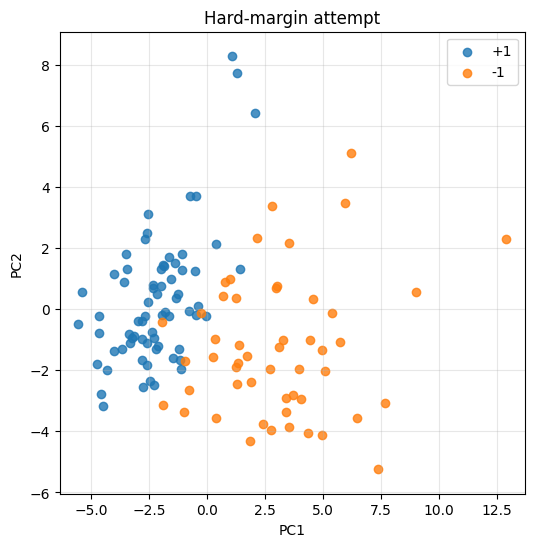

In [6]:
H_diag_hard, g_hard, hard_constr, bounds_hard= build_hard_margin_svm_qp(X, y)
res_hard = solve_qp_trust_constr(
    H_diag=H_diag_hard,
    g=g_hard,
    lin_constr=hard_constr,
    bounds=bounds_hard,
    z0=np.zeros(3),
    verbose=False,
)

print("Solver status:", res_hard.message)
print("Success:", res_hard.success)
print("Constraint violation (max):", getattr(res_hard, "constr_violation", None))
print("Objective value:", res_hard.fun)

z_hard = res_hard.x
w_hard = z_hard[:2]
b_hard = z_hard[2]

# Report empirical margins y*(w^T x + b)
margins_hard = y * (X @ w_hard + b_hard)
print("Min margin:", margins_hard.min(), "  Median margin:", np.median(margins_hard))

plot_separator_and_margins(X, y, w_hard, b_hard, title="Hard-margin attempt")

#### Soft-margin SVM

Soft-margin SVM allows **margin violations** via slack variables $\xi_i \ge 0$:

$$
\begin{aligned}
\min_{w,b,\xi}\quad & \frac{1}{2}\lVert w\rVert^2 + C\sum_{i=1}^n \xi_i \\
\text{s.t.}\quad & y_i(w^\top x_i + b) \ge 1 - \xi_i,\quad i=1,\ldots,n, \\
& \xi_i \ge 0,\quad i=1,\ldots,n.
\end{aligned}
$$

Equivalently, move $\xi_i$ to the left-hand side:

$$
y_i(w^\top x_i + b) + \xi_i \ge 1.
$$

---

## Subtask 3 — Soft-margin SVM

### Variables

We stack all decision variables into one vector:
$$
z =
\begin{bmatrix}
w_1 \\ w_2 \\ b \\ \xi_1 \\ \vdots \\ \xi_n
\end{bmatrix}
\in \mathbb{R}^{3+n}.
$$

### Constraints in matrix form

Let $\tilde X = [X\ \mathbf{1}] \in \mathbb{R}^{n\times 3}$ and define
$$
A_{\text{soft}} = \big[\ \mathrm{diag}(y)\tilde X\ \ \ I_n\ \big] \in \mathbb{R}^{n\times (3+n)}.
$$

Then the margin constraints become the single matrix inequality
$$
A_{\text{soft}} z \ge \mathbf{1},
$$
The nonnegativity of slack is enforced by $\xi_i \ge 0$ (already implemented in the code).

### Objective as a QP

This fits the QP template
$$
\min_z\ \frac{1}{2}z^\top H z + g^\top z
$$
with:
- $H = \mathrm{diag}(1,1,0,0,\ldots,0)$ (quadratic penalty only on $w$),
- $g = [0,0,0,\ C,\ldots,C]$ (linear penalty on $\xi$).

### Parameter $C$

The parameter $C>0$ controls the trade-off:
- **small $C$**: prefers a larger margin, tolerates more violations (larger $\xi$),
- **large $C$**: penalizes violations strongly, fits training data more aggressively (smaller $\xi$).

For this task we will take C as input.

In [9]:
def build_soft_margin_svm_qp(X: np.ndarray, y: np.ndarray, C: float):
    """
    Build the QP pieces for soft-margin SVM in the primal with variables
        z = [w1, w2, b, xi_1, ..., xi_n].

    Problem:
        minimize    0.5 * ||w||^2 + C * sum_i xi_i
        subject to  y_i (w^T x_i + b) >= 1 - xi_i   for all i
                    xi_i >= 0

    Returns
    -------
    X_tilde : np.ndarray, shape (n, 3)
        Augmented data matrix [X, 1]
    H_diag_soft : np.ndarray, shape (3+n,)
        Diagonal of Hessian (so H = diag(H_diag_soft))
    g_soft : np.ndarray, shape (3+n,)
        Linear term in objective
    A_soft : np.ndarray, shape (n, 3+n)
        Constraint matrix for A_soft @ z >= 1
    bounds_soft : scipy.optimize.Bounds
        Bounds object for z (enforces xi >= 0)
    """
    n, d = X.shape
    assert d == 2, "This helper assumes 2D features (w1,w2) for plotting."

    # Build the augmented feature matrix ~X = [X, 1]
    X_tilde = np.c_[X, np.ones(n)]

    dim_soft = 3 + n  # [w1, w2, b, xi_1..xi_n]

    # TODO (Soft-margin — objective):
    # Set up the objective for soft-margin SVM:
    #   minimize 0.5 * ||w||^2 + C * sum_i xi_i
    # using z = [w1, w2, b, xi_1..xi_n].

    H_diag_soft = np.zeros(dim_soft, dtype=float)
    H_diag_soft[0] = 1.0
    H_diag_soft[1] = 1.0
    g_soft = np.zeros(dim_soft, dtype=float)
    g_soft[3:] = C

    # Bounds: w,b are free; xi_i >= 0
    lb = np.full(dim_soft, -np.inf, dtype=float)
    ub = np.full(dim_soft, np.inf, dtype=float)
    lb[3:] = 0.0
    bounds_soft = Bounds(lb=lb, ub=ub)

    # TODO (Soft-margin — constraints):
    # Construct A_soft so that the constraints
    #   y_i (w^T x_i + b) + xi_i >= 1
    # become
    #   A_soft @ z >= 1   (elementwise)

    A_soft = np.zeros((n, 3 + n), dtype=float)
    soft_constr = LinearConstraint(A_soft, lb=np.ones(n), ub=np.inf*np.ones(n))
    A_soft[:, 0:2] = y[:, None] * X
    A_soft[:, 2] = y
    A_soft[np.arange(n), 3 + np.arange(n)] = 1.0

    return H_diag_soft, g_soft, soft_constr, bounds_soft


### Solve soft-margin SVM + visualize

Run after you define the constraints.
### The value of $C$

- Small $C$: larger margin but more violations (more training errors).
- Large $C$: fewer violations but potentially smaller margin (more “aggressive” fitting).

In this cell we will sobserve how the solution changes with $C$.

c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)



C = 0.1
Solver status: Constraint violation exceeds 'gtol'
Success: False
Constraint violation (max): 1.0
Objective value: 5.448994993678603e-07
Training accuracy: 0.15
Min margin: -3.899391012020007e-08 Median margin: -5.780739611578911e-09
Average slack: 4.5408291613589227e-08 Max slack: 4.540829161358952e-08


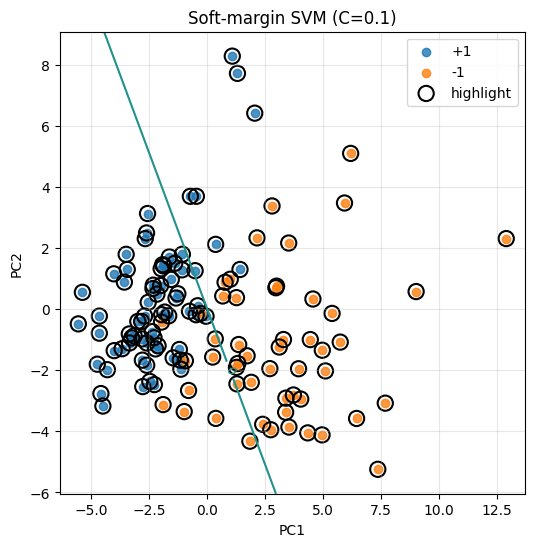

c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)



C = 1.0
Solver status: Constraint violation exceeds 'gtol'
Success: False
Constraint violation (max): 1.0
Objective value: 2.3250353048476772e-07
Training accuracy: 0.15
Min margin: -5.523712385845911e-05 Median margin: -8.217673523016282e-06
Average slack: 1.9374489519054894e-09 Max slack: 1.9374489519054898e-09


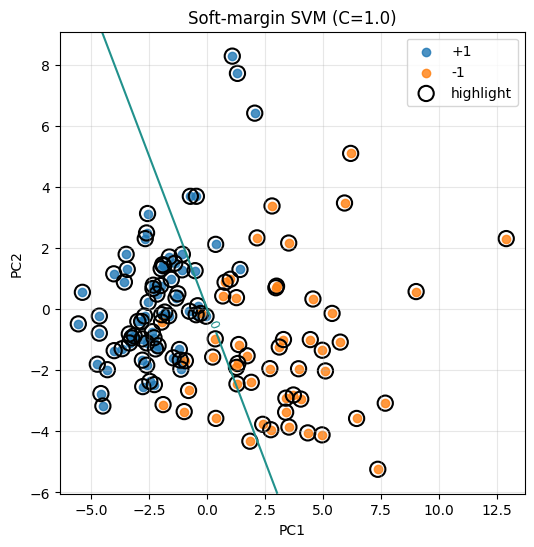

c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)



C = 10.0
Solver status: Constraint violation exceeds 'gtol'
Success: False
Constraint violation (max): 1.0
Objective value: 2.4576000000000005e-07
Training accuracy: 0.425
Min margin: -1.104904950122159e-24 Median margin: -1.104904950122159e-24
Average slack: 2.0480000000000006e-10 Max slack: 2.0480000000000014e-10


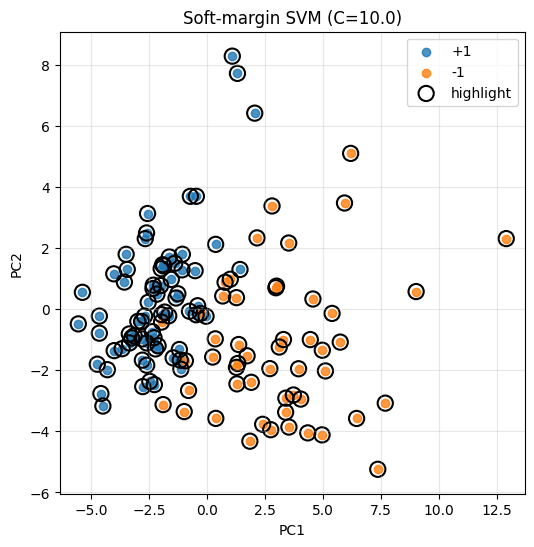

c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
c:\andra_saker\skola\Master\DATM\labs_DATM\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)



C = 100.0
Solver status: Constraint violation exceeds 'gtol'
Success: False
Constraint violation (max): 1.0
Objective value: 2.457599999725105e-07
Training accuracy: 0.575
Min margin: -1.1050266182070855e-24 Median margin: 1.1050266182070855e-24
Average slack: 2.0479999997709198e-11 Max slack: 2.0479999997709204e-11


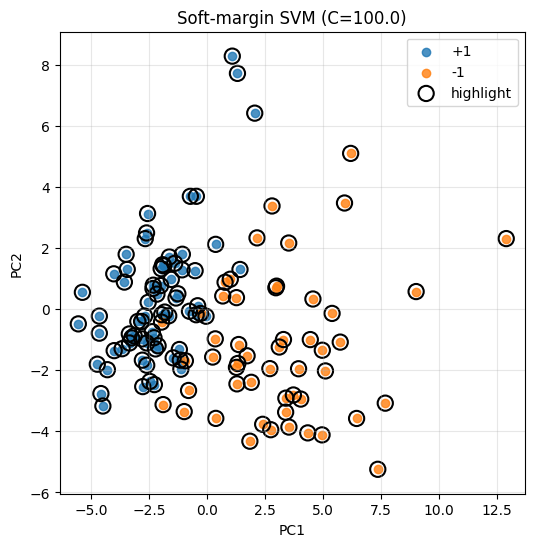

In [10]:
# A feasible initial point: w=0, b=0, xi=1 satisfies y*(0)+1 >= 1
z0 = np.zeros(3 + n, dtype=float)
z0[3:] = 1.0

# Four meaningful values of C (small -> large)
C_values = [0.1, 1.0, 10.0, 100.0]

for C in C_values:
    H_diag_soft, g_soft, soft_constr, bounds_soft = build_soft_margin_svm_qp(X, y, C)

    res_soft = solve_qp_trust_constr(
        H_diag=H_diag_soft,
        g=g_soft,
        lin_constr=soft_constr,
        bounds=bounds_soft,
        z0=z0,
        verbose=False,
    )

    print("\n" + "=" * 60)
    print(f"C = {C}")
    print("Solver status:", res_soft.message)
    print("Success:", res_soft.success)
    print("Constraint violation (max):", getattr(res_soft, "constr_violation", None))
    print("Objective value:", res_soft.fun)

    z_soft = res_soft.x
    w_soft = z_soft[:2]
    b_soft = z_soft[2]
    xi = z_soft[3:]

    scores = X @ w_soft + b_soft
    pred = np.sign(scores)
    pred[pred == 0] = 1  # tie-break
    acc = np.mean(pred == y)

    margins = y * scores
    print("Training accuracy:", acc)
    print("Min margin:", margins.min(), "Median margin:", np.median(margins))
    print("Average slack:", xi.mean(), "Max slack:", xi.max())

    # Support-vector-like points: close to or inside the margin
    supportish = margins <= 1.0 + 1e-3

    plot_separator_and_margins(
        X, y, w_soft, b_soft,
        title=f"Soft-margin SVM (C={C})",
        highlight=supportish
    )
